# QBL Carry-J Derivation

Each code cell tests one claim, prints `PASS` or `FAIL`, and emits exactly one inline figure. The notebook performs no file I/O.

## Claim 1: affine ceiling recurrence gives the carry/error map

PASS
c_A = ceil(2 E_(A-1) + gamma), A>=1
E_A = 2 E_(A-1) + gamma - c_A, A>=1
first carries: [9, 7, 8, 9, 7, 8, 9, 7, 8, 8, 8, 8]


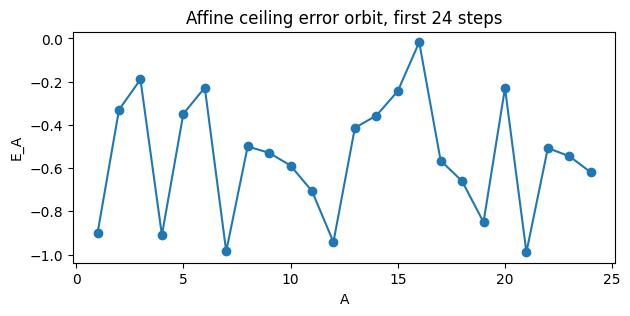

In [1]:
import math, numpy as np, sympy as sp, mpmath as mp
import matplotlib.pyplot as plt
mp.mp.dps = 100
phi = (1 + mp.sqrt(5))/2
lam = 6*mp.log(2)/mp.log(phi)
gamma = lam + mp.mpf('1.5') - mp.log(5)/(2*mp.log(phi))
a = (gamma - 8)/2
y0 = 2*lam - gamma
T0 = int(mp.ceil(y0))
E = y0 - T0
rows=[]
prev_T=T0
y=y0
for A in range(1,25):
    y = 2*y + gamma
    T = int(mp.ceil(y))
    c_direct = T - 2*prev_T
    c_map = int(mp.ceil(2*E + gamma))
    E_next = 2*E + gamma - c_map
    rows.append((A,c_direct,c_map,float(E_next)))
    prev_T=T; E=E_next
passed = all(cd==cm and -1 < en <= 0 for _,cd,cm,en in rows)
print('PASS' if passed else 'FAIL')
print('c_A = ceil(2 E_(A-1) + gamma), A>=1')
print('E_A = 2 E_(A-1) + gamma - c_A, A>=1')
print('first carries:', [r[1] for r in rows[:12]])
fig, ax = plt.subplots(figsize=(7,3))
ax.plot([r[0] for r in rows], [r[3] for r in rows], marker='o')
ax.set_xlabel('A'); ax.set_ylabel('E_A'); ax.set_title('Affine ceiling error orbit, first 24 steps')
plt.show()

## Claim 2: exact half-open endpoint convention and finite boundary separation

PASS
I7=(-1,-1/2-a], I8=(-1/2-a,-a], I9=(-a,0]
-1 A= 1868 distance= 0.0003478207810847098521247177227533873201485
b7 A= 1416 distance= 0.0000972886578265059463613837509126160593973
b8 A= 2845 distance= 0.0001620397523254952391777900167629464381686
0 A= 1417 distance= 0.0001945773156530118927227675018252321187946
boundary hits through A=10000: []


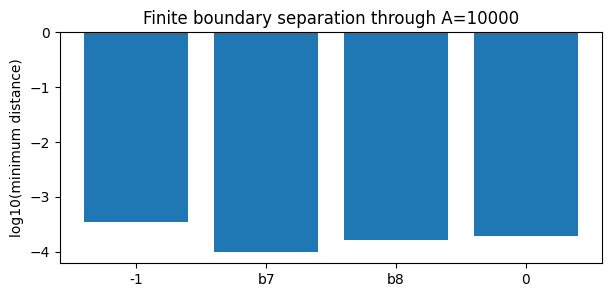

In [2]:
mp.mp.dps = 4500
phi = (1 + mp.sqrt(5))/2
lam = 6*mp.log(2)/mp.log(phi)
gamma = lam + mp.mpf('1.5') - mp.log(5)/(2*mp.log(phi))
a = (gamma - 8)/2
y0 = 2*lam - gamma
E = y0 - mp.ceil(y0)
bounds=[mp.mpf(-1), -mp.mpf('0.5')-a, -a, mp.mpf(0)]
names=['-1','b7','b8','0']
mins=[(abs(E-b),0) for b in bounds]
hits=[]
for A in range(1,10001):
    c=int(mp.ceil(2*E+gamma)); E=2*E+gamma-c
    for i,b in enumerate(bounds):
        d=abs(E-b)
        if d==0: hits.append((A,names[i]))
        if d<mins[i][0]: mins[i]=(d,A)
passed=(not hits and min(x[0] for x in mins)>0)
print('PASS' if passed else 'FAIL')
print('I7=(-1,-1/2-a], I8=(-1/2-a,-a], I9=(-a,0]')
for n,(d,A) in zip(names,mins): print(n,'A=',A,'distance=',mp.nstr(d,40))
print('boundary hits through A=10000:',hits)
fig, ax = plt.subplots(figsize=(7,3))
ax.bar(names,[float(mp.log10(d)) for d,_ in mins])
ax.set_ylabel('log10(minimum distance)'); ax.set_title('Finite boundary separation through A=10000')
plt.show()

## Claim 3: interval overlaps produce J with seven positive and two zero entries

PASS
J =


⎡       1   3⋅a  a⎤
⎢  0    ─ - ───  ─⎥
⎢       2    2   2⎥
⎢                 ⎥
⎢1   a           a⎥
⎢─ - ─    1/4    ─⎥
⎢4   2           2⎥
⎢                 ⎥
⎢1   a  3⋅a   1   ⎥
⎢─ - ─  ─── - ─  0⎥
⎣4   2   2    4   ⎦
numerical J =
 [[0.         0.14731655 0.11756115]
 [0.13243885 0.25       0.11756115]
 [0.13243885 0.10268345 0.        ]]


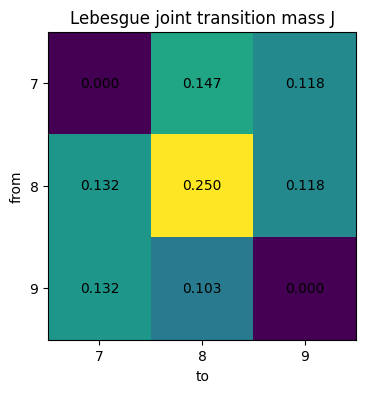

In [3]:
aa=sp.symbols('a', real=True)
J=sp.Matrix([[0,(1-3*aa)/2,aa/2],[(1-2*aa)/4,sp.Rational(1,4),aa/2],[(1-2*aa)/4,3*aa/2-sp.Rational(1,4),0]])
a_num=mp.mpf('0.23512230214539206396749493556637313041156271798112424182163855146037819991322335')
Jn=np.array(J.subs(aa,str(a_num)).evalf(30).tolist(),dtype=float)
positive_positions=[(0,1),(0,2),(1,0),(1,1),(1,2),(2,0),(2,1)]
passed=(J[0,0]==0 and J[2,2]==0 and all(Jn[i,j]>0 for i,j in positive_positions))
print('PASS' if passed else 'FAIL')
print('J ='); sp.pprint(J)
print('numerical J =\n',Jn)
fig, ax = plt.subplots(figsize=(5,4))
im=ax.imshow(Jn)
ax.set_xticks(range(3),['7','8','9']); ax.set_yticks(range(3),['7','8','9'])
ax.set_xlabel('to'); ax.set_ylabel('from'); ax.set_title('Lebesgue joint transition mass J')
for i in range(3):
    for j in range(3): ax.text(j,i,f'{Jn[i,j]:.3f}',ha='center',va='center')
plt.show()

## Claim 4: row sums, column sums, and total mass

PASS
row sums: [1/2 - a, 1/2, a]
column sums: [1/2 - a, 1/2, a]
total mass: 1


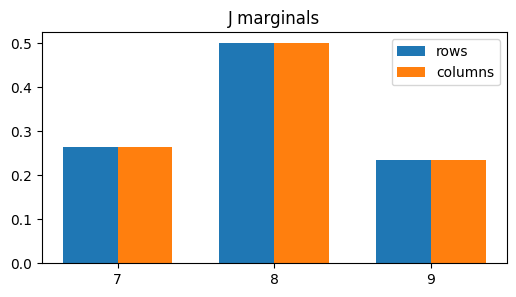

In [4]:
row_sums=[sp.simplify(sum(J[i,j] for j in range(3))) for i in range(3)]
col_sums=[sp.simplify(sum(J[i,j] for i in range(3))) for j in range(3)]
pi_expr=[sp.Rational(1,2)-aa,sp.Rational(1,2),aa]
total=sp.simplify(sum(J))
passed=(row_sums==pi_expr and col_sums==pi_expr and total==1)
print('PASS' if passed else 'FAIL')
print('row sums:',row_sums)
print('column sums:',col_sums)
print('total mass:',total)
fig, ax = plt.subplots(figsize=(6,3))
idx=np.arange(3); w=.35
ax.bar(idx-w/2,[float(x) for x in np.array(Jn).sum(axis=1)],width=w,label='rows')
ax.bar(idx+w/2,[float(x) for x in np.array(Jn).sum(axis=0)],width=w,label='columns')
ax.set_xticks(idx,['7','8','9']); ax.set_title('J marginals'); ax.legend()
plt.show()

## Claim 5: conditional P is stochastic and pi_Leb is stationary

PASS
P =
⎡         1 - 3⋅a     a   ⎤
⎢   0     ───────  ───────⎥
⎢         1 - 2⋅a  1 - 2⋅a⎥
⎢                         ⎥
⎢1/2 - a    1/2       a   ⎥
⎢                         ⎥
⎢1 - 2⋅a  6⋅a - 1         ⎥
⎢───────  ───────     0   ⎥
⎣  4⋅a      4⋅a           ⎦
row sums: [1, 1, 1]
pi P - pi: [0, 0, 0]


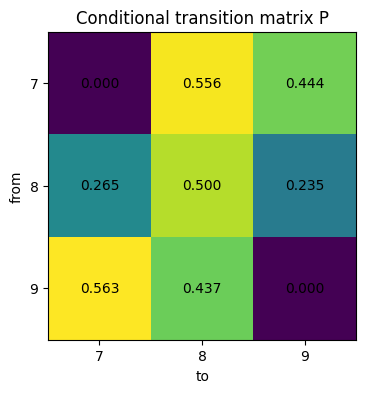

In [5]:
P=sp.Matrix([[0,(1-3*aa)/(1-2*aa),aa/(1-2*aa)],[(1-2*aa)/2,sp.Rational(1,2),aa],[(1-2*aa)/(4*aa),(6*aa-1)/(4*aa),0]])
pi=sp.Matrix([[sp.Rational(1,2)-aa,sp.Rational(1,2),aa]])
P_rows=[sp.simplify(sum(P[i,j] for j in range(3))) for i in range(3)]
station=[sp.simplify(x) for x in list(pi*P-pi)]
passed=(P_rows==[1,1,1] and station==[0,0,0])
print('PASS' if passed else 'FAIL')
print('P ='); sp.pprint(P)
print('row sums:',P_rows)
print('pi P - pi:',station)
Pn=np.array(P.subs(aa,str(a_num)).evalf(30).tolist(),dtype=float)
fig, ax = plt.subplots(figsize=(5,4))
ax.imshow(Pn)
ax.set_xticks(range(3),['7','8','9']); ax.set_yticks(range(3),['7','8','9'])
ax.set_xlabel('to'); ax.set_ylabel('from'); ax.set_title('Conditional transition matrix P')
for i in range(3):
    for j in range(3): ax.text(j,i,f'{Pn[i,j]:.3f}',ha='center',va='center')
plt.show()

## Claim 6: topological system is primitive with Perron root 1+sqrt(2)

PASS
M =
⎡0  1  1⎤
⎢       ⎥
⎢1  1  1⎥
⎢       ⎥
⎣1  1  0⎦
M^2 =
⎡2  2  1⎤
⎢       ⎥
⎢2  3  2⎥
⎢       ⎥
⎣1  2  2⎦
rho = 1 + sqrt(2)  entropy = log(1+sqrt(2))
Perron residual = [0, 0, 0]


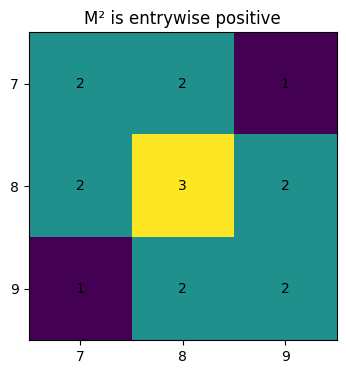

In [6]:
M=sp.Matrix([[0,1,1],[1,1,1],[1,1,0]])
M2=M**2
rho=1+sp.sqrt(2); r=sp.Matrix([1,sp.sqrt(2),1])
res=sp.simplify(M*r-rho*r)
passed=(all(x>0 for x in M2) and res==sp.zeros(3,1))
print('PASS' if passed else 'FAIL')
print('M ='); sp.pprint(M)
print('M^2 ='); sp.pprint(M2)
print('rho =',rho,' entropy = log(1+sqrt(2))')
print('Perron residual =',list(res))
fig, ax = plt.subplots(figsize=(5,4))
ax.imshow(np.array(M2.tolist(),dtype=float))
ax.set_xticks(range(3),['7','8','9']); ax.set_yticks(range(3),['7','8','9'])
ax.set_title('M² is entrywise positive')
for i in range(3):
    for j in range(3): ax.text(j,i,str(M2[i,j]),ha='center',va='center')
plt.show()

## Claim 7: Parry joint edge measure K is normalized

PASS
K =
⎡             √2        1    ⎤
⎢   0      ────────  ────────⎥
⎢          4 + 4⋅√2  4 + 4⋅√2⎥
⎢                            ⎥
⎢   √2        2         √2   ⎥
⎢────────  ────────  ────────⎥
⎢4 + 4⋅√2  4 + 4⋅√2  4 + 4⋅√2⎥
⎢                            ⎥
⎢   1         √2             ⎥
⎢────────  ────────     0    ⎥
⎣4 + 4⋅√2  4 + 4⋅√2          ⎦
row/column marginals: [1/4, 1/2, 1/4]
total mass: 1


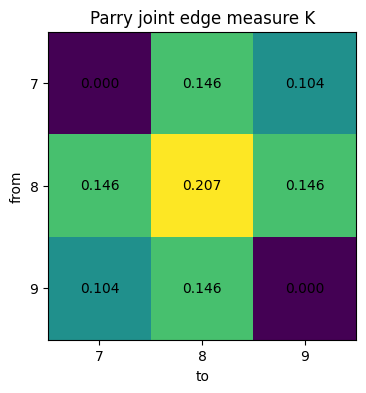

In [7]:
K=sp.Matrix([[0,sp.sqrt(2),1],[sp.sqrt(2),2,sp.sqrt(2)],[1,sp.sqrt(2),0]])/(4*(1+sp.sqrt(2)))
Krow=[sp.simplify(sum(K[i,j] for j in range(3))) for i in range(3)]
Kcol=[sp.simplify(sum(K[i,j] for i in range(3))) for j in range(3)]
Ktot=sp.simplify(sum(K))
passed=(Krow==[sp.Rational(1,4),sp.Rational(1,2),sp.Rational(1,4)] and Kcol==Krow and Ktot==1)
print('PASS' if passed else 'FAIL')
print('K ='); sp.pprint(K)
print('row/column marginals:',Krow)
print('total mass:',Ktot)
Kn=np.array(K.evalf(30).tolist(),dtype=float)
fig, ax = plt.subplots(figsize=(5,4))
ax.imshow(Kn)
ax.set_xticks(range(3),['7','8','9']); ax.set_yticks(range(3),['7','8','9'])
ax.set_xlabel('to'); ax.set_ylabel('from'); ax.set_title('Parry joint edge measure K')
for i in range(3):
    for j in range(3): ax.text(j,i,f'{Kn[i,j]:.3f}',ha='center',va='center')
plt.show()

## Claim 8: finite joint edge data are closer to J than to K

PASS
empirical joint =
 [[0.         0.14751475 0.11621162]
 [0.13161316 0.25682568 0.11581158]
 [0.13211321 0.09990999 0.        ]]
vs J (max,L1,TV)= (np.float64(0.00682568256825683), np.float64(0.014047774522984918), np.float64(0.007023887261492459))
vs K (max,L1,TV)= (np.float64(0.04971890138170931), np.float64(0.18401018949366277), np.float64(0.09200509474683138))


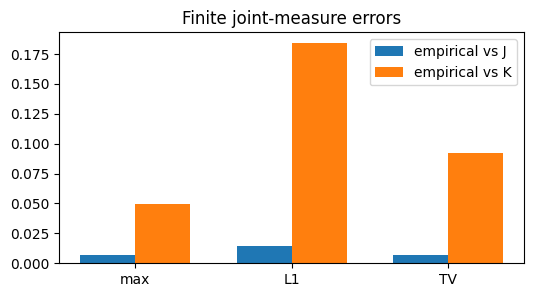

In [8]:
counts=np.array([[0,1475,1162],[1316,2568,1158],[1321,999,0]],dtype=int)
emp=counts/9999
errJ=np.abs(emp-Jn); errK=np.abs(emp-Kn)
metricsJ=(errJ.max(),errJ.sum(),errJ.sum()/2)
metricsK=(errK.max(),errK.sum(),errK.sum()/2)
passed=(abs(metricsJ[0]-0.00682568256825683)<1e-15 and abs(metricsJ[2]-0.00702388726149242)<1e-15 and abs(metricsK[0]-0.04971890138170926)<1e-15 and abs(metricsK[2]-0.0920050947468314)<1e-15)
print('PASS' if passed else 'FAIL')
print('empirical joint =\n',emp)
print('vs J (max,L1,TV)=',metricsJ)
print('vs K (max,L1,TV)=',metricsK)
fig, ax = plt.subplots(figsize=(6,3))
labels=['max','L1','TV']; x=np.arange(3); w=.35
ax.bar(x-w/2,metricsJ,width=w,label='empirical vs J')
ax.bar(x+w/2,metricsK,width=w,label='empirical vs K')
ax.set_xticks(x,labels); ax.set_title('Finite joint-measure errors'); ax.legend()
plt.show()

## Claim 9: state and defect frequencies retain the evidence-only boundary

PASS
state counts: [2637 5042 2321]  empirical: [0.2637 0.5042 0.2321]
Lebesgue states: [0.2648777 0.5       0.2351223]  Parry states: [0.25 0.5  0.25]
defect counts: [1321 2315 2568 2633 1162]
defect empirical: [0.13211321 0.23152315 0.25682568 0.26332633 0.11621162]
defect benchmark: [0.13243885 0.2351223  0.25       0.2648777  0.11756115]
Specific-orbit equidistribution: OPEN; finite agreement only.


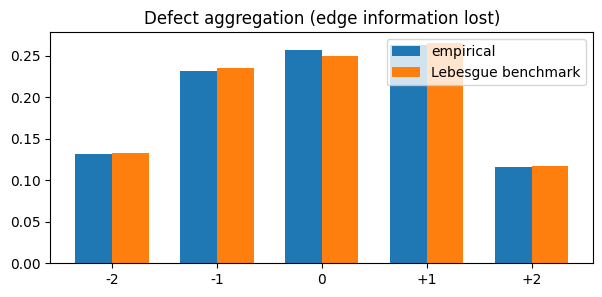

In [9]:
state_counts=np.array([2637,5042,2321]); state_emp=state_counts/10000
piL=np.array([0.5-float(a_num),0.5,float(a_num)]); piParry=np.array([.25,.5,.25])
def_counts=np.array([1321,2315,2568,2633,1162]); def_emp=def_counts/9999
def_bench=np.array([(1-2*float(a_num))/4,float(a_num),.25,.5-float(a_num),float(a_num)/2])
passed=(state_counts.sum()==10000 and def_counts.sum()==9999 and np.max(np.abs(def_emp-def_bench))<0.007)
print('PASS' if passed else 'FAIL')
print('state counts:',state_counts,' empirical:',state_emp)
print('Lebesgue states:',piL,' Parry states:',piParry)
print('defect counts:',def_counts)
print('defect empirical:',def_emp)
print('defect benchmark:',def_bench)
print('Specific-orbit equidistribution: OPEN; finite agreement only.')
fig, ax = plt.subplots(figsize=(7,3))
x=np.arange(5); w=.35
ax.bar(x-w/2,def_emp,width=w,label='empirical')
ax.bar(x+w/2,def_bench,width=w,label='Lebesgue benchmark')
ax.set_xticks(x,['-2','-1','0','+1','+2']); ax.set_title('Defect aggregation (edge information lost)'); ax.legend()
plt.show()

## Claim 10: the support law depends on 1/6 < a < 1/4

PASS
negative control a=1/10 is outside (1/6,1/4)
J98 = -1/10 ; the seven-positive-edge formula is invalid there


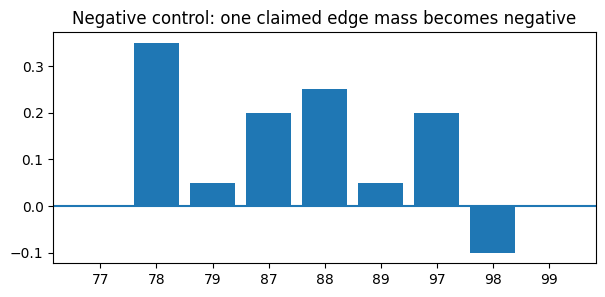

In [10]:
a_bad=sp.Rational(1,10)
Jbad=J.subs(aa,a_bad)
passed=(Jbad[2,1] < 0)
print('PASS' if passed else 'FAIL')
print('negative control a=1/10 is outside (1/6,1/4)')
print('J98 =',Jbad[2,1],'; the seven-positive-edge formula is invalid there')
vals=np.array(Jbad.evalf().tolist(),dtype=float).ravel()
fig, ax = plt.subplots(figsize=(7,3))
ax.bar(range(9),vals)
ax.axhline(0)
ax.set_xticks(range(9),['77','78','79','87','88','89','97','98','99'])
ax.set_title('Negative control: one claimed edge mass becomes negative')
plt.show()